# STAC-GP for short-horizon equity index futures (5m / 30m)

Runs the proposed **STAC-GP** method — a *static, frozen* Gaussian-process volatility-width model
with an *online localised conformal* calibration layer (thesis Algorithm 1) — on intraday futures
bars, at both 5-minute and 30-minute horizons.

The model forecasts the **half-width** of the next move (point forecast $\hat Y=0$, martingale):
a start-of-day realised-vol prior $w^{\text{prior}}$ is rescaled intraday by a GP factor
$g(x)=\exp(f(x))$, and the band is calibrated online with a covariate-localised, recency-weighted,
adaptive-level conformal threshold. All logic lives in `stac_gp.py`.

## 1. Load the module

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys; from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# make sure stac_gp.py is importable (it sits next to this notebook in the Thesis folder)
HERE = Path.cwd()
for cand in [HERE, *HERE.parents]:
    if (cand / "stac_gp.py").exists():
        sys.path.insert(0, str(cand)); break
from stac_gp import STACGP, ColumnMap
print("stac_gp loaded from:", [p for p in sys.path if (Path(p)/'stac_gp.py').exists()][:1])

stac_gp loaded from: ['/mnt/c/Users/Maxim/Documents/Thesis']


## 2. Data

**Expected schema.** One CSV of intraday bars for a single contract at a fixed frequency, in
chronological order. Required: a timestamp column and a mid/close column. Optional columns are used
as extra features if present.

| column | meaning | required |
|---|---|---|
| `timestamp` | bar-close datetime (parseable) | **yes** |
| `close` | mid price (or set to `(bid+ask)/2` upstream) | **yes** |
| `high`, `low` | bar high / low → range feature | no |
| `volume` | bar volume → liquidity feature | no |
| `ofi` | order-flow imbalance | no |
| `queue` | queue depth / liquidity proxy | no |
| `event` | scheduled-event flag (0/1), known ahead | no |

Sessions are inferred from the calendar date of `timestamp`; the horizon change is always computed
**within** a session (never across the overnight gap). Rename your columns via `ColumnMap(...)` if
they differ from the defaults.

Set `DATA_CSV` to your file and `USE_SMOKE_TEST = False`.

In [2]:
# ---- point this at your intraday bars (ES / NQ / ...) ----
DATA_CSV = ""                     # e.g. r"C:\\data\\ES_1min.csv"
BAR_MINUTES = 1                   # native bar size of your file, in minutes
HORIZONS   = [5, 30]              # forecast horizons in minutes
COLS = ColumnMap(timestamp="timestamp", close="close", high="high", low="low",
                 volume="volume", ofi="ofi", queue="queue", event="event")

# ---- SMOKE TEST: synthetic bars so the notebook runs before real data is wired in. ----
# ---- Set USE_SMOKE_TEST = False once DATA_CSV points at your file. ----
USE_SMOKE_TEST = True

def _synth_intraday(n_sessions=40, bars_per_session=390, seed=1):
    """Toy intraday futures: U-shaped session vol, day-level vol clustering, event jumps."""
    rng = np.random.RandomState(seed); rows = []; price = 5000.0
    for s in range(n_sessions):
        day = pd.Timestamp("2024-01-02") + pd.Timedelta(days=s)
        base = 0.6 * np.exp(rng.randn() * 0.4)           # day vol regime (clustering)
        event_day = rng.rand() < 0.15
        for b in range(bars_per_session):
            tod = b / (bars_per_session - 1)
            u = 1.0 + 1.8 * ((tod - 0.5) ** 2) * 4        # U-shape (high near open/close)
            sig = base * u
            if event_day and abs(b - bars_per_session // 3) < 3: sig *= 4.0   # event burst
            price += rng.randn() * sig
            ts = day + pd.Timedelta(hours=9, minutes=30) + pd.Timedelta(minutes=b)
            rows.append((ts, price, price + abs(rng.randn())*sig*0.5,
                         price - abs(rng.randn())*sig*0.5, price,
                         max(1, int(1000*np.exp(rng.randn()*0.3))), 1.0 if event_day else 0.0))
    return pd.DataFrame(rows, columns=["timestamp","close","high","low","open","volume","event"])

if USE_SMOKE_TEST:
    bars = _synth_intraday()
    print("SMOKE TEST DATA (synthetic) — set USE_SMOKE_TEST=False and load DATA_CSV for real runs.")
else:
    bars = pd.read_csv(DATA_CSV)
    bars[COLS.timestamp] = pd.to_datetime(bars[COLS.timestamp])

bars = bars.sort_values(COLS.timestamp).reset_index(drop=True)
n_sessions = pd.to_datetime(bars[COLS.timestamp]).dt.normalize().nunique()
print(f"bars: {len(bars)}   sessions: {n_sessions}")
bars.head()

SMOKE TEST DATA (synthetic) — set USE_SMOKE_TEST=False and load DATA_CSV for real runs.
bars: 15600   sessions: 40


,timestamp,close,high,low,open,volume,event
0,2024-01-02 09:30:00,4998.031817,4999.322219,4997.309737,4998.031817,717,1.0
1,2024-01-02 09:31:00,4992.743897,4996.520783,4990.929585,4992.743897,737,1.0
2,2024-01-02 09:32:00,4994.767489,4996.132569,4991.953519,4994.767489,716,1.0
3,2024-01-02 09:33:00,4995.339031,4996.228990,4994.445657,4995.339031,1244,1.0
4,2024-01-02 09:34:00,4996.507647,4997.343881,4996.363568,4996.507647,1775,1.0


## 3. Run STAC-GP at each horizon

Earlier sessions fit-and-freeze the GP width; later sessions are the online test stream. Key knobs:

- `alpha` = target miscoverage (0.10 → 90% bands)
- `gamma` = online level step size (feedback strength); `None` → $0.5/\sqrt{T}$
- `R` = calibration window; `rho` = recency decay; `h` = localiser bandwidth (`None` → median heuristic)
- `gp_features` / `loc_features` default to all features / the vol-state subset

In [3]:
results = {}
for Hmin in HORIZONS:
    model = STACGP(horizon_minutes=Hmin, bar_minutes=BAR_MINUTES,
                   alpha=0.10, gamma=0.05, R=300, rho=0.99,
                   kernel="rbf", cols=COLS)
    res = model.fit_run(bars, train_frac=0.5)
    results[Hmin] = res
    print(f"\n===== horizon {Hmin}m  (H_bars={res.meta['H_bars']}, "
          f"localiser h={res.meta['h']:.3f}, gamma={res.meta['gamma']:.4f}) =====")
    print("GP features :", res.meta['gp_features'])
    print("localiser   :", res.meta['loc_features'])
    print(res.summary().to_string(index=False, formatters={
        'coverage':'{:.3f}'.format, 'target':'{:.2f}'.format, 'avg_width':'{:.3f}'.format,
        'median_width':'{:.3f}'.format, 'width_vol':'{:.3f}'.format, 'inf_rate':'{:.3f}'.format}))


===== horizon 5m  (H_bars=5, localiser h=4.054, gamma=0.0500) =====
GP features : ['tod_frac', 'ret_recent', 'rv', 'rng', 'vol_z', 'event']
localiser   : ['rv', 'rng', 'ret_recent', 'event']
          scope    n coverage target avg_width median_width width_vol inf_rate
            all 7315    0.897   0.90     8.758        6.838     1.142    0.000
    vol Q1 calm 1829    0.864   0.90     4.168        3.795     0.507    0.000
         vol Q2 1829    0.889   0.90     6.280        5.625     0.902    0.000
         vol Q3 1828    0.909   0.90     9.265        8.111     1.323    0.000
vol Q4 stressed 1829    0.924   0.90    15.321       12.714     2.329    0.000

===== horizon 30m  (H_bars=30, localiser h=4.466, gamma=0.0500) =====
GP features : ['tod_frac', 'ret_recent', 'rv', 'rng', 'vol_z', 'event']
localiser   : ['rv', 'rng', 'ret_recent', 'event']
          scope    n coverage target avg_width median_width width_vol inf_rate
            all 6840    0.892   0.90    17.379       13.322  

## 4. Diagnostics

Rolling coverage should track the 0.90 target; band width should breathe with the volatility regime.

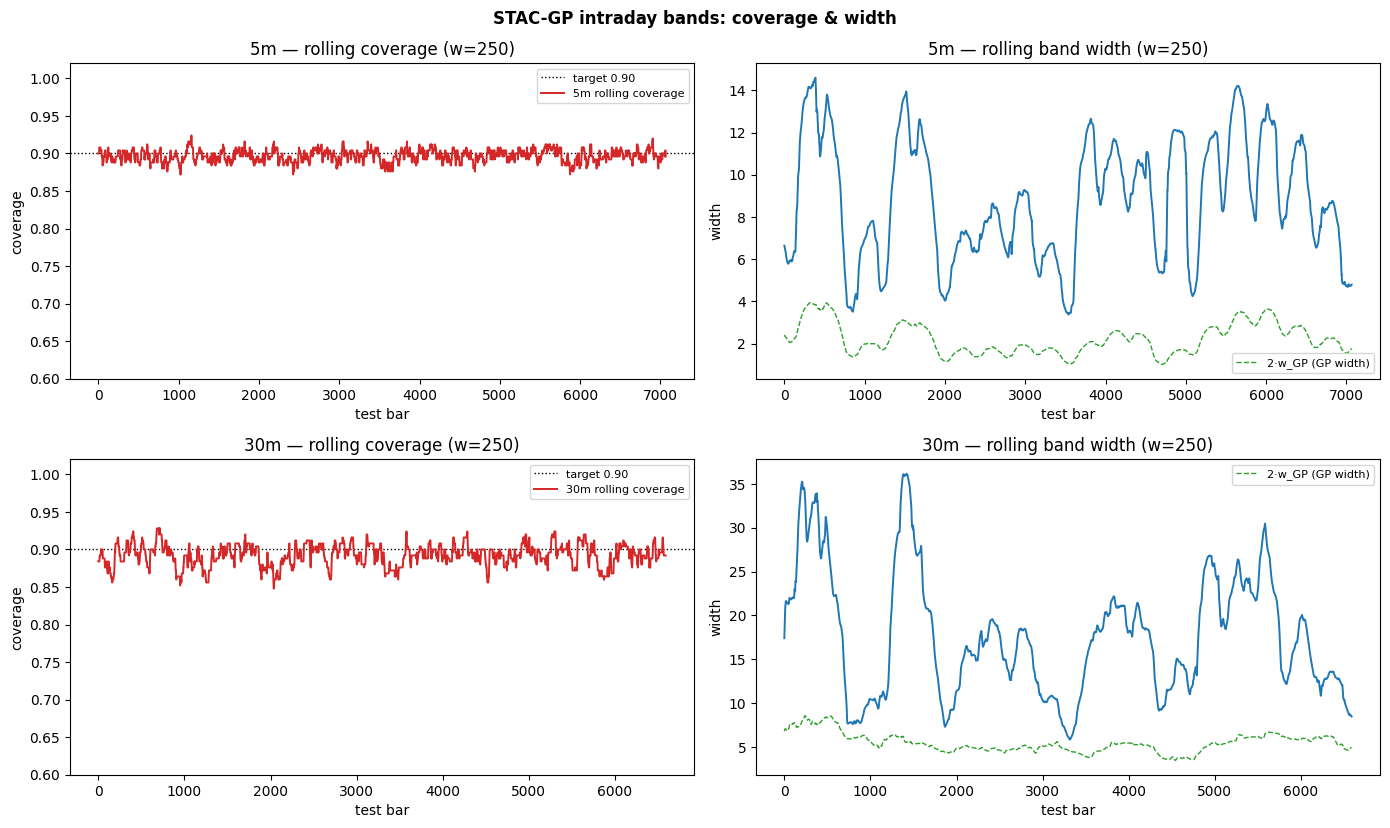

In [4]:
def rolling(a, w):
    a = np.asarray(a, float)
    return a if len(a) < w else np.convolve(a, np.ones(w)/w, mode="valid")

fig, ax = plt.subplots(len(HORIZONS), 2, figsize=(14, 4.2*len(HORIZONS)), squeeze=False)
for row, Hmin in enumerate(HORIZONS):
    f = results[Hmin].frame.reset_index(drop=True)
    W = max(20, min(250, len(f)//4))
    cov = rolling(f["covered"].to_numpy(), W)
    wid = rolling(f["width"].replace([np.inf,-np.inf], np.nan).to_numpy(), W)
    x = np.arange(len(cov))
    ax[row][0].axhline(0.90, color="k", ls=":", lw=1, label="target 0.90")
    ax[row][0].plot(x, cov, color="C3", lw=1.4, label=f"{Hmin}m rolling coverage")
    ax[row][0].set(title=f"{Hmin}m — rolling coverage (w={W})", xlabel="test bar", ylabel="coverage",
                   ylim=(0.6, 1.02)); ax[row][0].legend(fontsize=8)
    ax[row][1].plot(rolling(f["width"].to_numpy(), W), color="C0", lw=1.4)
    ax[row][1].plot(rolling(f["w_GP"].to_numpy()*2, W), color="C2", lw=1.0, ls="--", label="2·w_GP (GP width)")
    ax[row][1].set(title=f"{Hmin}m — rolling band width (w={W})", xlabel="test bar", ylabel="width")
    ax[row][1].legend(fontsize=8)
fig.suptitle("STAC-GP intraday bands: coverage & width", fontweight="bold")
plt.tight_layout(); plt.show()

### 4.1 Bands on a slice of the test stream (5m)

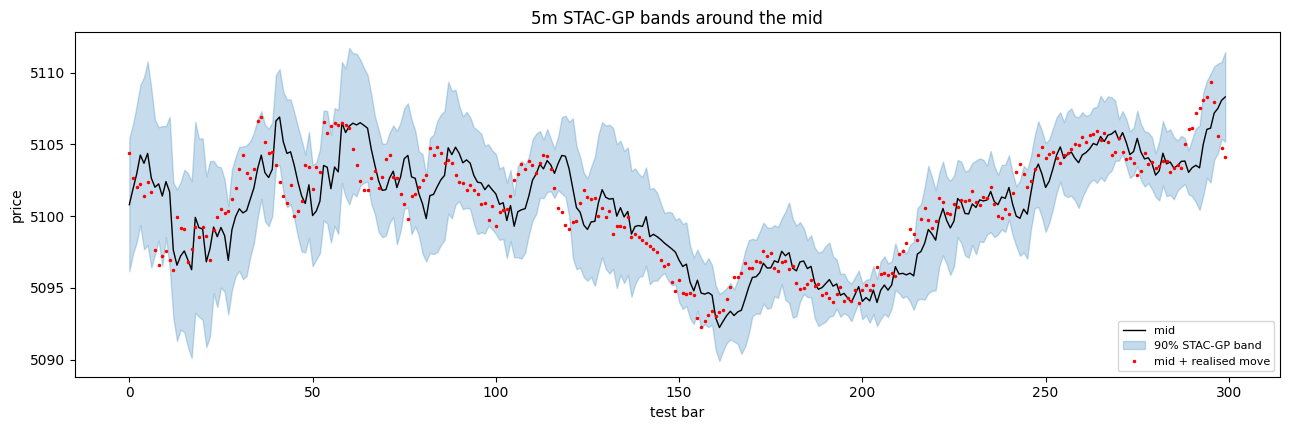

In [5]:
f = results[HORIZONS[0]].frame.reset_index(drop=True)
seg = slice(0, min(300, len(f)))
g = f.iloc[seg]
fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(g.index, g["mid"], "k-", lw=1.0, label="mid")
half = g["width"].to_numpy()/2.0
ax.fill_between(g.index, g["mid"]-half, g["mid"]+half, alpha=0.25, color="C0",
                label=f"{int((1-results[HORIZONS[0]].alpha)*100)}% STAC-GP band")
# mark the realised move landing point (mid + Y) to eyeball coverage
ax.plot(g.index, g["mid"] + g["Y"], "r.", ms=3, label="mid + realised move")
ax.set(title=f"{HORIZONS[0]}m STAC-GP bands around the mid", xlabel="test bar", ylabel="price")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 4.2 Realised returns vs. the conformal band (return space)

STAC-GP's point forecast is $\hat Y=0$ (martingale), so the object being forecast is the **band
half-width**, not a return level. This plot shows the realised move $Y_t$ against the $\pm q_t\,w^{GP}_t$
conformal band centred at 0 — points outside the band are misses (~10% by design). The dashed line
is the raw GP width $\pm w^{GP}_t$ *before* the conformal correction, so you can see what the online
localised calibration adds on top of the GP.

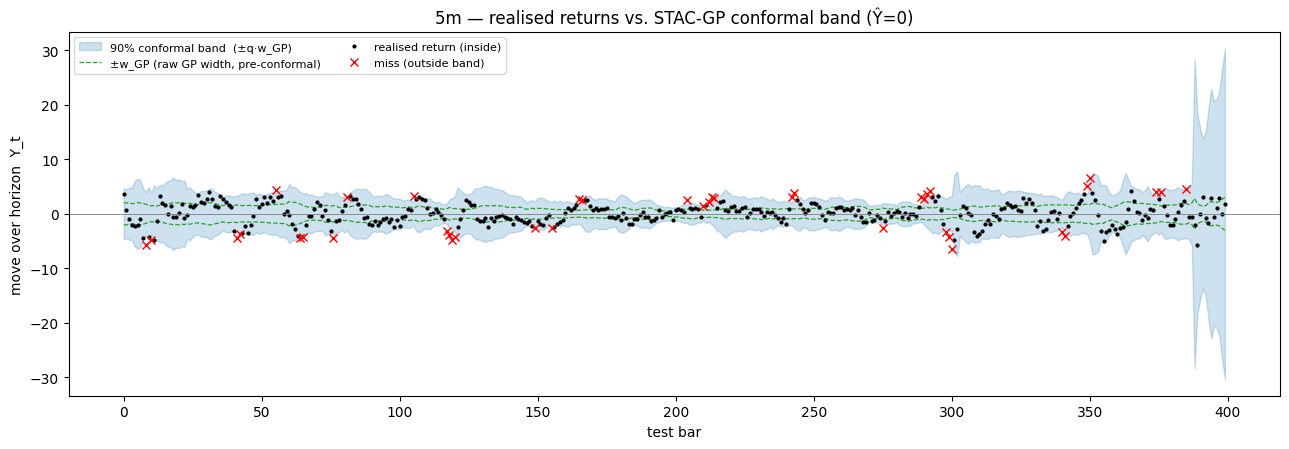

empirical coverage on this slice: 0.900  (target 0.90)


In [6]:
f = results[HORIZONS[0]].frame.reset_index(drop=True)
alpha = results[HORIZONS[0]].alpha
g = f.iloc[:min(400, len(f))]
half = g["width"].to_numpy() / 2.0
Y = g["Y"].to_numpy()
wg = g["w_GP"].to_numpy()
miss = np.abs(Y) > half

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.fill_between(g.index, -half, half, alpha=0.22, color="C0",
                label=f"{int((1-alpha)*100)}% conformal band  (±q·w_GP)")
ax.plot(g.index,  wg, color="C2", ls="--", lw=0.9, label="±w_GP (raw GP width, pre-conformal)")
ax.plot(g.index, -wg, color="C2", ls="--", lw=0.9)
ax.plot(g.index[~miss], Y[~miss], "k.", ms=4, label="realised return (inside)")
ax.plot(g.index[miss],  Y[miss],  "rx", ms=6, label="miss (outside band)")
ax.axhline(0, color="grey", lw=0.6)
ax.set(title=f"{HORIZONS[0]}m — realised returns vs. STAC-GP conformal band (Ŷ=0)",
       xlabel="test bar", ylabel="move over horizon  Y_t")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
print(f"empirical coverage on this slice: {(~miss).mean():.3f}  (target {1-alpha:.2f})")

## 5. Notes & knobs

- **Real data:** set `USE_SMOKE_TEST=False`, `DATA_CSV`, and `BAR_MINUTES` to your file's native bar
  size. `HORIZONS` are in minutes; the code maps them to `round(H/BAR_MINUTES)` bars.
- **σ0 (start-of-day prior):** realised-vol only — trailing EWMA of squared bar returns fixed at each
  session open, Brownian-scaled by $\sqrt{H}$. Tune via `sigma0_lookback_sessions`, `ewma_halflife_bars`.
- **Localisation:** `loc_features` defaults to the vol-state subset (`rv, rng, ret_recent, event`).
  Bandwidth `h=None` uses a median heuristic; pass a float to fix it. `rho`<1 adds recency decay
  (eq. 10); `R` sets the window.
- **Coverage is marginal**, not conditional — expect the regime-stratified coverage to vary around
  0.90 even when the overall figure is on target; localisation buys *efficiency* (right-sized bands
  by regime), per the thesis.
- **Performance:** exact GP fit is capped at `n_gp_max` training points (uniform subsample); the
  online loop is O(T·R). For very long files, raise `n_gp_max` cautiously or subsample bars.
- **Bid–offer benchmark, asymmetric bands, OLCP-Hedge bandwidth selection** (thesis §5, §7.1) are
  natural next additions on top of the per-bar `results[H].frame`.